In [18]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
%matplotlib inline

import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

In [20]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

# Get data

In [21]:
path = os.path.join("..", "..", "data", "assets.h5")
with pd.HDFStore(path) as store:
    data = store['engineered_features']

In [22]:
data.columns

Index(['return_1d', 'return_2d', 'return_5d', 'return_20d', 'return_130d',
       'return_260d', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'momentum_1',
       'momentum_2', 'momentum_5', 'momentum_20', 'momentum_130',
       'momentum_260', 'momentum_130_260', 'day', 'year', 'month', 'weekday',
       'return_1d_t-1', 'return_1d_t-2', 'return_1d_t-3', 'return_1d_t-4',
       'return_1d_t-5', 'return_1d_t-6', 'target_1d', 'target_2d', 'target_5d',
       'target_20d', 'target_130d', 'target_260d'],
      dtype='object')

# Create dummy variables

In [23]:
dummy_data = pd.get_dummies(data,
                            columns=['year','month'],
                            prefix=['year','month'],
                            prefix_sep=['_', '_'])
dummy_data = dummy_data.rename(columns={c:c.replace('.0', '') for c in dummy_data.columns})
dummy_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 64 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   return_1d         501517 non-null  float64
 1   return_2d         501517 non-null  float64
 2   return_5d         501517 non-null  float64
 3   return_20d        501517 non-null  float64
 4   return_130d       501517 non-null  float64
 5   return_260d       501517 non-null  float64
 6   Mkt-RF            501517 non-null  float64
 7   SMB               501517 non-null  float64
 8   HML               501517 non-null  float64
 9   RMW               501517 non-null  float64
 10  CMA               501517 non-null  float64
 11  momentum_1        501517 non-null  float64
 12  momentum_2        501517 non-null  float64
 13  momentum_5        501517 non-null  float64
 14  momentum_20       501517 non-

# Mutual information

## Original data

In [33]:
target_labels = [f'target_{i}d' for i in [1,2,5,20,130, 260]]
targets = data.dropna().loc[:, target_labels]

features = data.dropna().drop(target_labels, axis=1)

cat_cols = ['year', 'month', 'day', 'weekday']
discrete_features = [features.columns.get_loc(c) for c in cat_cols]

In [34]:
mutual_info = pd.DataFrame()
for label in target_labels:
    mi = mutual_info_classif(X=features, 
                             y=(targets[label]> 0).astype(int),
                             discrete_features=discrete_features,
                             random_state=42
                            )
    mutual_info[label] = pd.Series(mi, index=features.columns)

In [35]:
mutual_info.sum()

target_1d      1.521932
target_2d      1.638683
target_5d      1.709973
target_20d     1.573145
target_130d    1.430307
target_260d    1.433786
dtype: float64

## Normalized MI Heatmap

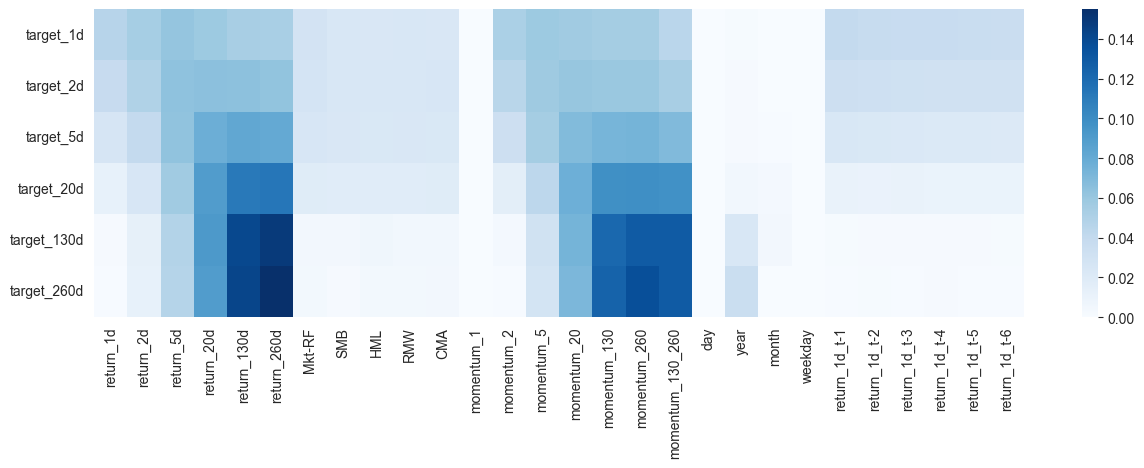

In [36]:
fig, ax= plt.subplots(figsize=(15, 4))
sns.heatmap(mutual_info.div(mutual_info.sum()).T, ax=ax, cmap='Blues');

## Dummy Data

In [38]:
target_labels = [f'target_{i}d' for i in [1,2,5,20,130, 260]]
dummy_targets = dummy_data.dropna().loc[:, target_labels]

dummy_features = dummy_data.dropna().drop(target_labels, axis=1)
cat_cols = [c for c in dummy_features.columns if c not in features.columns]
discrete_features = [dummy_features.columns.get_loc(c) for c in cat_cols]

In [39]:
mutual_info_dummies = pd.DataFrame()
for label in target_labels:
    mi = mutual_info_classif(X=dummy_features, 
                             y=(dummy_targets[label]> 0).astype(int),
                             discrete_features=discrete_features,
                             random_state=42
                            )    
    mutual_info_dummies[label] = pd.Series(mi, index=dummy_features.columns)

In [40]:
mutual_info_dummies.sum()

target_1d      1.540219
target_2d      1.656392
target_5d      1.727552
target_20d     1.586546
target_130d    1.448099
target_260d    1.450234
dtype: float64

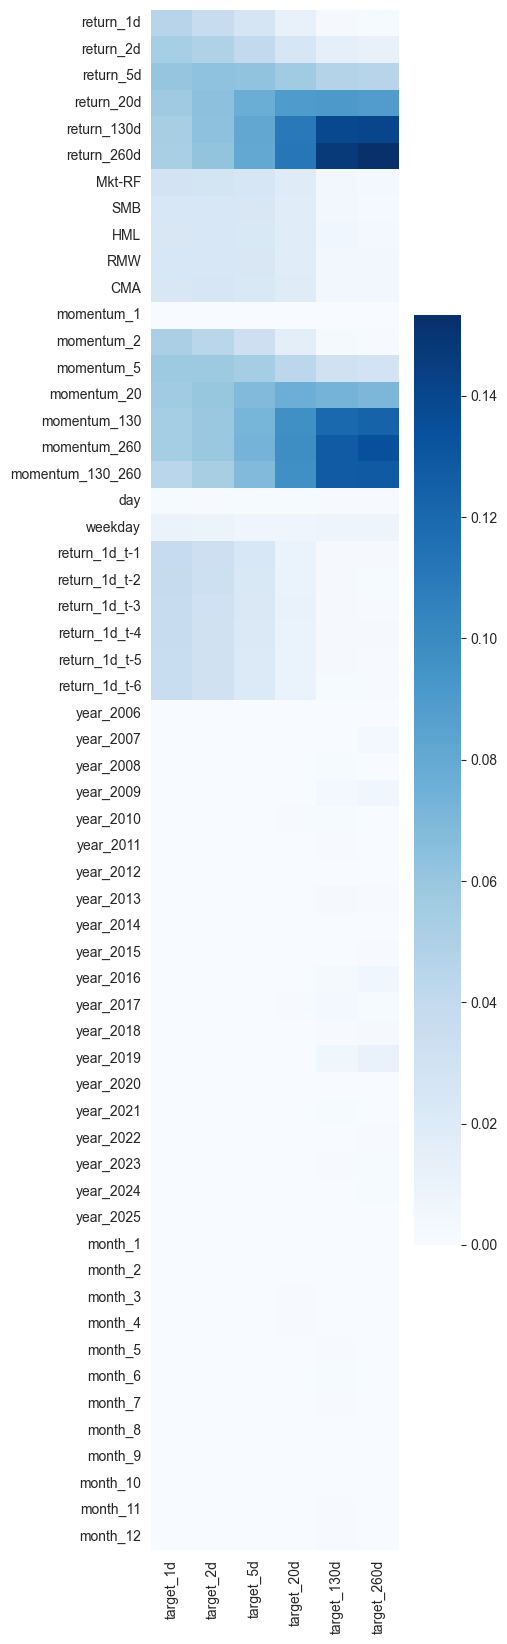

In [41]:
fig, ax= plt.subplots(figsize=(4, 20))
sns.heatmap(mutual_info_dummies.div(mutual_info_dummies.sum()), ax=ax, cmap='Blues');